# Soc5044 Computational Sociology W15 Practicum - GenAI

These teaching materials are for the course "Soc5044 Computational Sociology" lectured at the sociology department of National Taiwan University by Dr. Chen-Shuo Hong.

Editor: Jun-Wei Liu (b09902009@ntu.edu.tw)

---

# 1. LLMs Basic Usage

In this notebook, we will use `Gemini` from Google instead of `GPT` from OpenAI (because it gives free quota). However if you're interested in using GPT, you can refer to the [Developer quickstart](https://platform.openai.com/docs/quickstart?api-mode=responses&lang=python) page at OpenAI Platform.

The following examples are adapted from [Gemini API documents](https://ai.google.dev/gemini-api/docs/quickstart?lang=python). Checkout the documents for more details and advanced usage.
- [Text generation](https://ai.google.dev/gemini-api/docs/text-generation)
- [Image understanding](https://ai.google.dev/gemini-api/docs/image-understanding)
- [Generate images](https://ai.google.dev/gemini-api/docs/image-generation)

## Set up & quick start!

The first step is to sign up for the Gemini API access with Google. Go to [Google AI Studio](https://aistudio.google.com/apikey), click "Create API key", and then copy the value to the variable below.

In [ ]:
GOOGLE_API_KEY = "PASTE_YOUR_API_KEY_HERE"

Then we install the `google-genai` package to later call the API.

In [25]:
!pip install -q -U google-genai

Let's see if everything works!

In [ ]:
from google import genai

client = genai.Client(api_key=GOOGLE_API_KEY)

response = client.models.generate_content(
    model="gemini-2.0-flash", # choose a model to use
    contents=["Write a bedtime story about a unicorn."] # your prompt
)
print(response.text)
print(f'Word count: {len(response.text.split())}')

Deep in the Whispering Woods, nestled amongst trees that sparkled with fireflies and flowers that hummed with sleepy bees, lived a little unicorn named Lumi. Lumi wasn't like the other unicorns. While they pranced and preened, admiring their shimmering horns in crystal clear pools, Lumi preferred quiet adventures.

Tonight, a soft lavender dusk had settled over the Whispering Woods. The moon, a sliver of pearly light, peeked through the canopy. Lumi, her coat the color of starlight, was restless. She hadn't had an adventure today, and her little hooves were itching to explore.

She tiptoed past the other unicorns, all snoozing soundly in a meadow of moon-kissed clover. She slipped through the whispering leaves and into the heart of the woods.

As she walked, the forest whispered secrets to her. The wind rustled through the trees, singing a lullaby about the stars. Fireflies winked and blinked, guiding her path. She smelled the sweet scent of honeysuckle and the earthy aroma of moss.

S

## Configure parameters

Every prompt you send to the model includes parameters that control how the model generates responses. You can configure these parameters, or let the model use the default options.

- `max_output_tokens`: Sets the maximum number of tokens to include in a candidate.
- `temperature`: Controls the randomness of the output. Use higher values for more creative responses, and lower values for more deterministic responses. Values can range from [0.0, 2.0].

In [ ]:
from google.genai import types

client = genai.Client(api_key=GOOGLE_API_KEY)

response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents=["Write a bedtime story about a unicorn."],
    config=types.GenerateContentConfig(
        max_output_tokens=200,
        temperature=0.1
    )
)
print(response.text)
print(f'Word count: {len(response.text.split())}')

Once upon a time, nestled in a valley where the moonbeams kissed the dew-kissed grass, lived a unicorn named Luna. Luna wasn't just any unicorn. Her coat shimmered with all the colors of the twilight sky, and her horn, instead of being pure white, swirled with shades of lavender, rose, and a touch of stardust silver.

Luna loved the night. While the other unicorns grazed in the sunlit meadows, Luna would wait patiently for the first star to twinkle. Then, she would venture out, her hooves barely making a sound on the soft earth.

Tonight, Luna felt a little lonely. The fireflies, usually her companions, were unusually quiet. The crickets, usually chirping their nightly song, were hushed. Even the moon seemed to be hiding behind a veil of wispy clouds.

"Oh dear," Luna sighed, her breath misting in the cool night air. "What's happened to all the joy
Word count: 148


By limiting the maximum number of tokens, the story gets cut off before it finishes.

## Multi-turn conversations

The Gemini SDK lets you collect multiple rounds of questions and responses into a chat. The chat format enables users to step incrementally toward answers and to get help with multipart problems. This SDK implementation of chat provides an interface to keep track of conversation history, but behind the scenes it uses the same generateContent method to create the response.

In [33]:
client = genai.Client(api_key=GOOGLE_API_KEY)

chat = client.chats.create(model="gemini-2.0-flash")

response = chat.send_message("I have 2 dogs in my house.")
print(response.text)

response = chat.send_message("How many paws are in my house?")
print(response.text)

for message in chat.get_history():
    print(f'role - {message.role}',end=": ")
    print(message.parts[0].text)

Okay! Two dogs, that's great. Do you want to tell me anything else about them? Like their names, breeds, or personalities? I'm ready to listen!

Since you have 2 dogs and each dog has 4 paws, there are 8 paws in your house.

role - user: I have 2 dogs in my house.
role - model: Okay! Two dogs, that's great. Do you want to tell me anything else about them? Like their names, breeds, or personalities? I'm ready to listen!

role - user: How many paws are in my house?
role - model: Since you have 2 dogs and each dog has 4 paws, there are 8 paws in your house.



## Images as input

The Gemini API supports multimodal inputs that combine text and media files. The following example ask Gemini to describe the photo below. The photo is taken when US President Donald Trump holds a chart as he delivers remarks on reciprocal tariffs during an event in the Rose Garden entitled "Make America Wealthy Again" at the White House in Washington, DC, on April 2, 2025.

Phote credit: Getty Images.

![trump](./trump.jpg)

In [43]:
from PIL import Image

# Read the image
image = Image.open("./trump.jpg")

client = genai.Client(api_key=GOOGLE_API_KEY)

response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents=[image, "Describe this image."]
)

print(response.text)

The image shows Donald Trump standing behind a podium with a microphone, speaking to an audience. Behind him, there's an American flag, and to his right, he is holding up a sign titled "Reciprocal Tariffs". The sign lists various countries and the "Tariffs Charged to the U.S.A." and "U.S.A. Dis. Reciprocal" rates. Some of the countries listed on the sign include China, the European Union, Vietnam, and Taiwan, each with its respective tariff percentages.


## Images as output

Gemini 2.0 Flash Experimental supports the ability to output text and inline images. This lets you use Gemini to conversationally edit images or generate outputs with interwoven text (for example, generating a blog post with text and images in a single turn).

Note that all generated images include a [SynthID watermark](https://ai.google.dev/responsible/docs/safeguards/synthid), and images in Google AI Studio include a visible watermark as well.

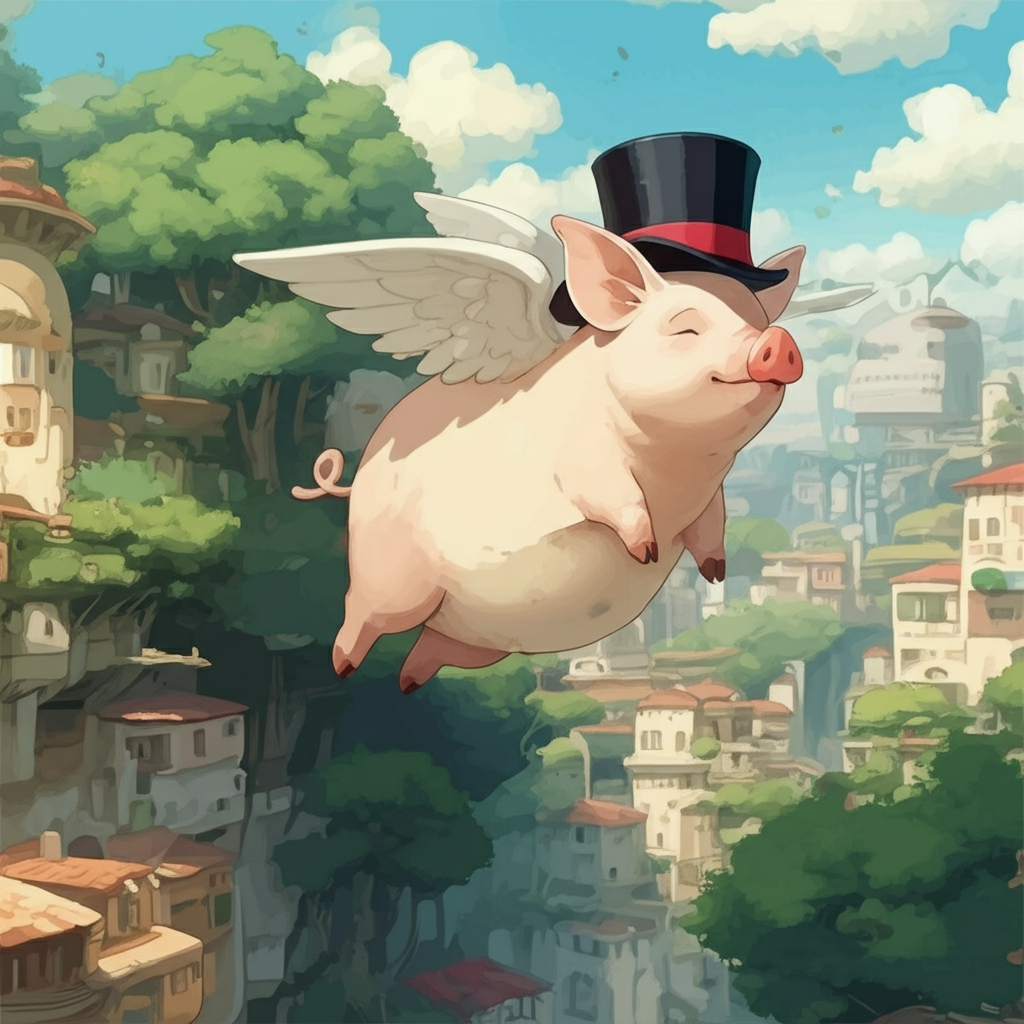

In [49]:
from google.genai import types
from PIL import Image
from io import BytesIO

client = genai.Client(api_key=GOOGLE_API_KEY)

text_input = ('Hi, can you create a Ghibli-styled image of a pig '
            'with wings and a top hat flying over a happy '
            'futuristic scifi city with lots of greenery?')

response = client.models.generate_content(
    model="gemini-2.0-flash-exp-image-generation",
    contents=[text_input],
    config=types.GenerateContentConfig(
        response_modalities=['TEXT', 'IMAGE']
    )
)

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = Image.open(BytesIO((part.inline_data.data)))
        display(image)
        image.save('gemini-generated-image.png') # save the image

You can also use images as input and ask for images as output (i.e., image editing). Let's add some animals to Trump.

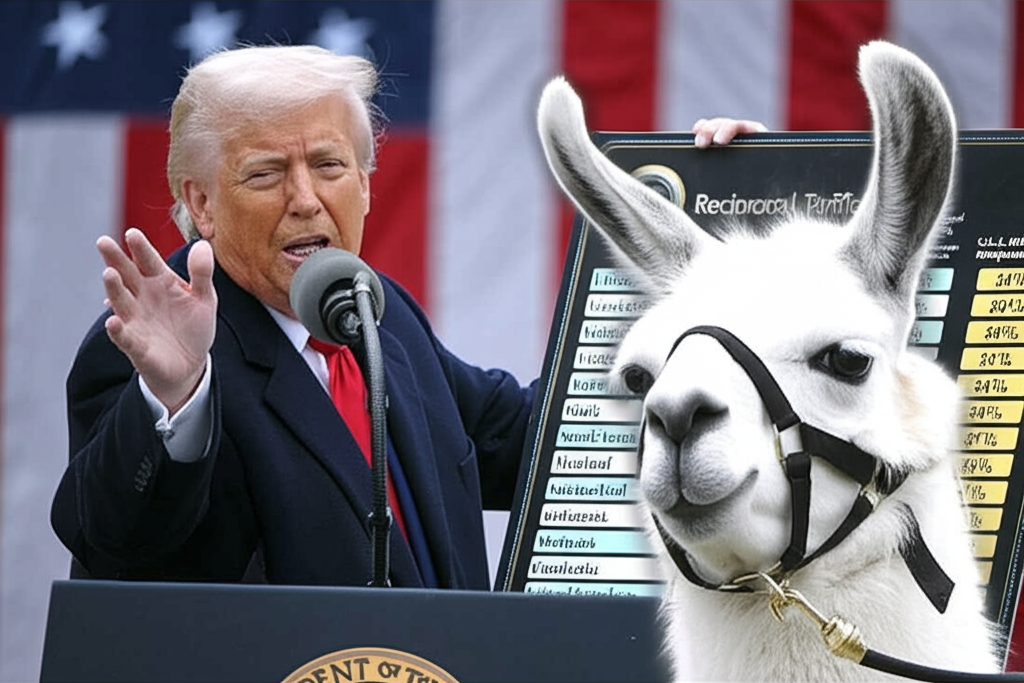

In [55]:
from google.genai import types
from PIL import Image
from io import BytesIO

image = Image.open("./trump.jpg")

text_input = ('Hi, This is a picture of Donald Trump.'
            'Can you add a llama next to him?',)

client = genai.Client(api_key=GOOGLE_API_KEY)

response = client.models.generate_content(
    model="gemini-2.0-flash-exp-image-generation",
    contents=[text_input, image],
    config=types.GenerateContentConfig(
        response_modalities=['TEXT', 'IMAGE']
    )
)

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = Image.open(BytesIO((part.inline_data.data)))
        display(image)
        image.save('trump-llama.png') # save the image

# 2. LLMs for text analysis

The following example is adapted from "How to Use LLMs for text analysis" by [Petter Törnberg](https://www.uva.nl/en/profile/t/o/p.tornberg/k.p.tornberg.html#Profile). Petter Törnberg is Assistant Professor at the Institute for Language, Logic and Computation at the University of Amsterdam, Associate Professor in Complex Systems at Chalmers University of Technology, NWO VENI laurate, and senior researcher at the University of Neuchâtel.

> Petter Törnberg (2023). How to Use LLMs for text analysis. https://github.com/cssmodels/howtousellms/blob/main/HowToUseLLMsNotebook.ipynb

---

This notebook is associated to a how-to guide that gives a simple introduction to using Large Language Models for text analysis in the social sciences. The guide is aimed at students and researchers who are interested in using LLMs for their quantitative or qualitative social scientific text analysis, but who have limited programming experience. 

The notebook offers the code for the example of analyzing the level of populism in a given political text, but can easily be adapted for your particular text analysis project.

## Loading and preparing your data

In our example, we will use the data from the [Global Populism Dataset](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/LFTQEZ). This data offers a number of texts from politicians, and can be used for validating our method. The texts are provided as .txt files in a folder. We will load all these files into a single dataframe.

In [135]:
import glob
import pandas as pd
import os 

# Define the folder path where the text files are located
folder_path = './global-populism-dataset/speeches_20220427/'

# Use glob to get a list of all *.txt files in the folder
txt_files = glob.glob(folder_path + '/*.txt')

# Create an empty list to store the data
data = []

# Loop through each text file
for file_path in txt_files:
    with open(file_path, 'r',encoding='utf-8',errors='ignore') as file:
        # Read the text from the file
        text = file.read()

        # Get the filename without the directory path
        filename = os.path.basename(file_path)

        # Append the text and filename to the data list
        data.append({'filename': filename, 'text': text})

# Create a dataframe with the data
df = pd.DataFrame(data)

You will likely need to filter out and select the data you wish to include. 

In our case, we will filter out texts with non-latin alphabets. While Gemini can handle languages with non-latin characters, it is currently more expensive, and there are issues with managing text length. For simplicity, we therefore remove the texts with non-latin alphabet.


In [136]:
def is_latin_alphabet(text):
    latin_characters = 0
    total_characters = 0

    for char in text:
        if ord(char) >= 0x0000 and ord(char) <= 0x007F:
            latin_characters += 1
        total_characters += 1

    # Check if the majority of characters are Latin alphabet characters
    if latin_characters / total_characters >= 0.9:
        return True
    else:
        return False

df = df[df['text'].apply(is_latin_alphabet)]

## Prompt engineering

The next step is to formulate a first instructions for analyzing the text. The prompts will be a result of an iterative process through which you develop a formulation of the concept that you wish to capture. 

We here start by drawing on the instructions for human coders from a previous study.

In [137]:
instruction = """Your task is to evaluate the level of populism in a political text. Populism is defined as "an ideology that considers society to be ultimately separated into two homogeneous and antagonistic groups, 'the pure people' versus 'the corrupt elite', and which argues that politics should be an expression of the volonté générale (general will) of the people."
A populist text is characterized by BOTH of the following elements:
- People-centrism: how much does the text focus on "the people" or "ordinary people" as an indivisible or homogeneous community? Does the text promote a politics as the popular will of "the people"?
Appeals to specific subgroups of the population (such as ethnicities, regional groups, classes) are inherently antithetical to populism.
- Anti-elitism: how much does the text focus on "the elite", and to what extent are elites in general described in negative terms? In populist texts, the elite is often described as corrupt, and the juxtaposition between the ordinary people and the elite is cast as a moral struggle between good and bad. 
Criticism of specific elements within an elite is not populist: a populist appeal must regard the elite in its entirety as anathema. 

You should give the text a numeric grade between 0 and 2.
2. The text is very populist and comes very close to the ideal populist discourse.
1. A speech in this category includes strong expressions of all of the populist elements,  but either does not use them consistently or tempers them by including non-populist elements. The text may have a romanticized notion of the people and the idea of a unified popular will, but it avoids bellicose language or any particular enemy.
0. A speech in this category uses few if any populist elements. 
[Answer with a number in the 0-2 range, followed by a semi-colon, and then a brief motivation. For instance: "1.23; The text shows many elements of a populist text." Do not use quotation marks.]
"""

## Calling the LLM and analyzing the results

We will now write simple functions for calling the API and carry out our analysis request. We will also need to handle possible errors returned from the API.

In [138]:
from google.genai import types

client = genai.Client(api_key=GOOGLE_API_KEY)

def analyze_message(text, instruction, model='gemini-2.0-flash', temperature=0.2):
    print(f"Analyzing message...")

    response = client.models.generate_content(
        model=model,
        contents=[instruction, text],
        config=types.GenerateContentConfig(
            temperature=temperature
        )
    )

    return response.text

The LLM will return a text message. We need to parse this response so that we can use it for further analysis. The details of this function will depend on how you asked the API to respond in your instruction (see above). In our case, we asked the LLM to return a list of numbers, followed by a motivation.

In [ ]:
def parse_result(result):
    # The LLMs at times surround their answers with quotation marks, even if you explicitly tell them not to. If so, we remove them here.
    result = result.strip("'\"") 
    try:
        # We asked the LLM to start with a number, followed by a semi-colon, followed by the motivation. We assume this format in the response here.
        return result.split(';', 2)
    except Exception as e:
        print(result)
        pass

This is the main loop of the code, where we call the LLM for each line in our data, and give it the instructions.

In [140]:
#First, we need to prepare the data and store it in a file for persistency
filename = 'data.pkl'

#These are the columns where we will store the analyzed data
df['answers'] = [pd.NA for _ in range(len(df))]
df['motivations'] = [pd.NA for _ in range(len(df))]

df.to_pickle(filename)

In [152]:
import time

df = pd.read_pickle(filename)

# If you want to limit the number of lines to analyze
maximum_lines_to_analyze = 10

analyzed_lines_count = 0
while(True):
    # Find unprocessed lines and randomly select one
    left = df.loc[df['answers'].isna()]
    if len(left) == 0 or analyzed_lines_count >= maximum_lines_to_analyze:
        print(f"Processed {len(df) - len(left)}/{len(df)} lines.")
        break
        
    line  = left.sample()
    index = line.index.values[0]
    
    print(f"There are {len(left)} left to process. Processing: {index}")
    
    # Gemini set limits for "Requests per minute" (RPM), "Requests per day" (RPD), and "Tokens per minute" (TPM).
    # For the Gemini-2.0-Flash model, the limits for free tier users are:
    #   - RPM: 15
    #   - RPD: 1,500
    #   - TPM: 1,000,000
    # To not overload the API, wait a bit between requests and limits the number of requests
    time.sleep(0.8)
    
    # Analyze the sampled line
    result = analyze_message(line['text'].values[0], instruction)
    try:
        answer, motivation = parse_result(result)
        df.loc[index, 'answers'] = float(answer)
        df.loc[index, 'motivations'] = motivation
    
        analyzed_lines_count += 1
    
        # Save the result to persistent file
        df.to_pickle(filename)
    except Exception as e:
        print(e)
        print(f"LLM gives an invalid format {parse_result(result)}")

There are 902 left to process. Processing: 699
Analyzing message...
There are 901 left to process. Processing: 389
Analyzing message...
There are 900 left to process. Processing: 979
Analyzing message...
There are 899 left to process. Processing: 602
Analyzing message...
There are 898 left to process. Processing: 592
Analyzing message...
There are 897 left to process. Processing: 448
Analyzing message...
There are 896 left to process. Processing: 356
Analyzing message...
There are 895 left to process. Processing: 145
Analyzing message...
There are 894 left to process. Processing: 443
Analyzing message...
There are 893 left to process. Processing: 1154
Analyzing message...
Processed 31/923 lines.


### Example result

We can now look at some examples of the result from the analysis and the associated motivation. 

In [153]:
processed = df.loc[df['answers'].notna()]
example = processed.sample()
print(f"File: {example.filename.values[0]}")
print(f"Text: {example.text.values[0]}")
print(f"Rating: {example.answers.values[0]}")
print(f"Motivation: {example.motivations.values[0]}")

File: France_Macron_Famous_1.txt
Text: Discours d'investiture du président de la République
Publié le 15 Mai 2017 
Rubrique : Nation, institutions et réforme de l'Etat

SEUL LE PRONONCE FAIT FOI
Mesdames, Messieurs,
Les Français ont choisi, vous l’avez rappelé, le 7 mai dernier, l’espoir et l’esprit de conquête.
Le monde entier a regardé notre élection présidentielle. Partout, on se demandait si les Français allaient décider à leur tour de se replier sur le passé illusoire, s’ils allaient rompre avec la marche du monde, quitter la scène de l’Histoire, céder à la défiance démocratique, l’esprit de division et tourner le dos aux Lumières, ou si au contraire ils allaient embrasser l’avenir, se donner collectivement un nouvel élan, réaffirmer leur foi dans les valeurs qui ont fait d’eux un grand peuple.
Le 7 mai, les Français ont choisi. Qu’ils en soient ici remerciés.
La responsabilité qu’ils m’ont confiée est un honneur, dont je mesure la gravité.
Le monde et l’Europe ont aujourd’hui, pl

At face value, this motivation seems both reasonable and plausible. We will now turn to carry out a more in-depth validation.

## Validation

Finally, we need to validate our results. Careful validation is essential to make sure that the models are measuring what we intend -- and that they do so without problematic biases. To validate our models, we can compare the outputs with established benchmarks, ground truth data, or expert evaluations to validate the effectiveness in achieving the desired analysis outcomes. Validation can furthermore help us fine-tune the model prompt to improve the results.

A simple way of validating can be to output a random sample to an Excel file, and have human coders manually classifying the data to compare the results. To do so, the code below can be used:

### Acquire validation data

In the case of the populism example, however, the Global Populism Database already offers a large sample of manually classified datapoints that we can use for validation. 

In [154]:
# Include only the lines that we've coded with the LLM
df_processed = df.loc[df['answers'].notna()]
df_processed = df_processed[['filename', 'answers', 'motivations']]
df_processed['codernum'] = 'llm'

# Load and clean the validation data
val = pd.read_csv('./global-populism-dataset/gpd_v2_20220427.csv')
val = val[['merging_variable', 'codernum', 'averagerubric']].rename(columns={'merging_variable':'filename', 'averagerubric':'answers'})
val = val[val['filename'].notna()] 
val = val.drop_duplicates(subset=['filename'], keep='first')
val['codernum'] = val['codernum'].astype(float)

processed_files = set(df_processed.filename.values)
val = val.loc[(val['filename'].isin(processed_files)) & (val['codernum']<=2)]
val['codernum'] = 'human'

# Combine the two datasets
validation_data = pd.concat([val, df_processed])

validation_data

,filename,codernum,answers,motivations
420,Bolivia_Morales_Campaign_3.txt,human,0.95,NaN
480,Bolivia_Morales_Ribbon_1.txt,human,0.5,NaN
572,Brazil_Bolsonaro_Campaign_1.txt,human,0.9,NaN
788,Chile_Lagos_Ribbon_1.txt,human,0.333333,NaN
848,Chile_Pinera_Campaign_1.txt,human,0.0,NaN
...,...,...,...,...
783,Philippines_Aquino III_Ribbon_1.txt,llm,1.0,"The text uses the term ""Boss"" to refer to the..."
979,Spain_Rajoy_Ribbon_1.txt,llm,0.0,The speech focuses on the inauguration of a h...
1042,Turkey_Erdogan_Campaign_1.txt,llm,1.0,"The speech contains some populist elements, s..."
1147,Venezuela_Chavez_Campaign_2.txt,llm,1.0,"The text focuses heavily on ""the people"" (pue..."


### Measure Krippendorf's Alpha

To compare our data against the validation data, we can use Krippendorf's Alpha. We here use the simpledorff library to do so.

In [155]:
!pip install simpledorff

Defaulting to user installation because normal site-packages is not writeable


In [156]:
import simpledorff

# Calculate inter-coder reliability
# Note that this uses the interval metric. If your variable is categorical, you need to remove the metric_fn parameter.
KA = simpledorff.calculate_krippendorffs_alpha_for_df(validation_data, metric_fn=simpledorff.metrics.interval_metric, experiment_col='filename', annotator_col='codernum', class_col='answers')

print(f"The resulting Krippendorf's Alpha is is {KA}.")

The resulting Krippendorf's Alpha is is 0.42482777440459574.


This is a relatively high value for a first iteration of prompt development for a challenging concept.


### Carry out iterative process of concept and prompt development 

Having measured the disagreements between coders and LLM, we can now seek to try to understand the sources of the disagreement. This can be best thought of as a process of mutual learning through which we develop and operationalize a rigorous social scientific concept in the form of a prompt.

We can here work with the coders, and comparing their notes to the motivations given by the LLM, focusing on the examples where the LLM and the human coders are (most) in disagreement. We may find that the prompt can be improved - or that our human coders were mistaken or biased. 

In our case, we do not have access to the coders, and we will simply show the process through which this form of work can be done.

In [157]:
# Create a dataframe that lists the level of disagreement between coders and LLM
val = val.rename(columns={'answers':'answer_human'})
val = val[['filename', 'answer_human']]
df_processed = df_processed.rename(columns={'answers':'answer_llm'})
df_processed = df_processed[['filename', 'answer_llm', 'motivations']]

wrong = df_processed.merge(val, on='filename')
wrong['diff'] = abs(wrong['answer_human'] - wrong['answer_llm'])
wrong = wrong.sort_values(['diff'], ascending=False)

wrong

,filename,answer_llm,motivations,answer_human,diff
10,El Salvador_Funes_International_1.txt,1.0,The text focuses on the need for development ...,0.000000,1.0
19,Lithuania_Adamkus_Famous_1.txt,1.0,The text contains some elements of populism. ...,0.000000,1.0
5,Chile_Pinera_Campaign_1.txt,1.0,"The text focuses on ""the people"" and their ne...",0.000000,1.0
15,Honduras_Flores_Famous_1.txt,1.0,The speech contains some people-centric rheto...,0.150000,0.85
26,Philippines_Aquino III_Ribbon_1.txt,1.0,"The text uses the term ""Boss"" to refer to the...",0.150000,0.85
22,Netherlands_Balkenende_Campaign_2.txt,1.0,"The text focuses on ""we"" and ""togetherness"" a...",0.200000,0.8
30,Venezuela_Chavez_International_3.txt,1.0,"The text focuses on ""the people"" of South Ame...",1.800000,0.8
9,Ecuador_Moreno_Ribbon_1.txt,1.0,"The text contains some elements of populism, ...",0.250000,0.75
12,France_Macron_Famous_1.txt,1.0,"The text focuses on ""the French people"" and t...",0.300000,0.7
0,Australia_Howard_Famous_1.txt,1.0,"The speech focuses on ""the Australian people""...",0.350000,0.65
